# [Stacking - classification](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html#sklearn.ensemble.StackingClassifier)

In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn import datasets
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import os
import random
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
#    torch.manual_seed(seed)
#    torch.cuda.manual_seed(seed)
#    torch.backends.cudnn.deterministic = True
#    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
data = datasets.load_iris()

In [4]:
X_data = data.data
y_data = data.target

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2) # train과 test를 8:2로 분할

In [6]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
    ('svc', LinearSVC(random_state=42))
]

model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

In [7]:
model.fit(X_train, y_train)

,estimators,"[('rf', ...), ('svc', ...)]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [8]:
y = model.predict(X_train)

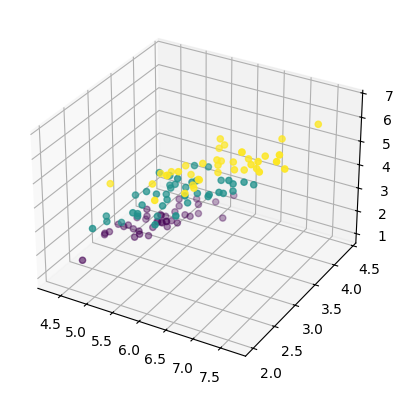

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y_train)
plt.show()

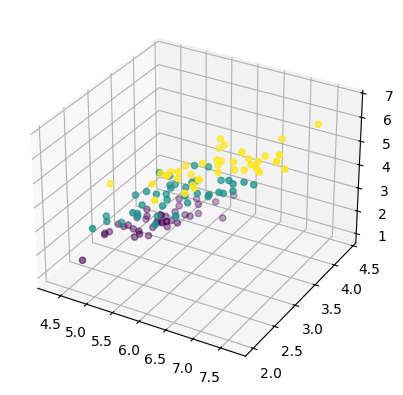

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y)
plt.show()

In [11]:
print(model.score(X_train, y_train))

0.9916666666666667


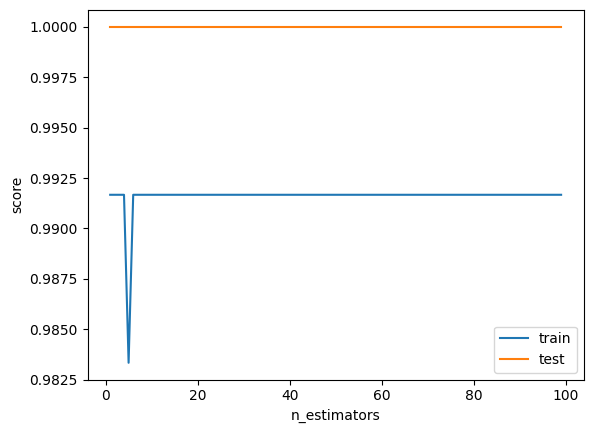

In [12]:
train_score = []
test_score = []
n_range = range(1, 100)

for n in n_range:
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=n, random_state=42)),
        ('svc', LinearSVC(random_state=42))
    ]

    model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    test_score.append(model.score(X_test, y_test))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, test_score, label='test')
plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('score')
plt.show()